In [1]:
import numpy as np

from cr_knee_fit import experiments
from cr_knee_fit.fit_data import CRSpectrumData, GenericExperimentData


def load_gamma_spectrum(fname: str, custom_label: str):
    E_TeV, F, Fstat, Fsyst = np.loadtxt(fname, unpack=True)
    Fconv = 1e-3 * 1e4  # TeV^-1 cm^-2 -> GeV^-1 m^-2

    return CRSpectrumData(
        d=GenericExperimentData(
            x=E_TeV * 1e3,
            y=F * Fconv,
            err_stat=np.vstack((Fstat, Fstat)).T * Fconv,
            err_syst=np.vstack((Fsyst, Fsyst)).T * Fconv,
            experiment=experiments.Experiment("LHAASO", "LHAASO"),
            custom_label=custom_label,
        ),
        spec="gamma",
        quantity="E",
    )

In [2]:
gamma_outer = load_gamma_spectrum("../data/lake/LHAASO_outerGalaxy.txt", " (outer)")
gamma_inner = load_gamma_spectrum("../data/lake/LHAASO_innerGalaxy.txt", " (inner)")

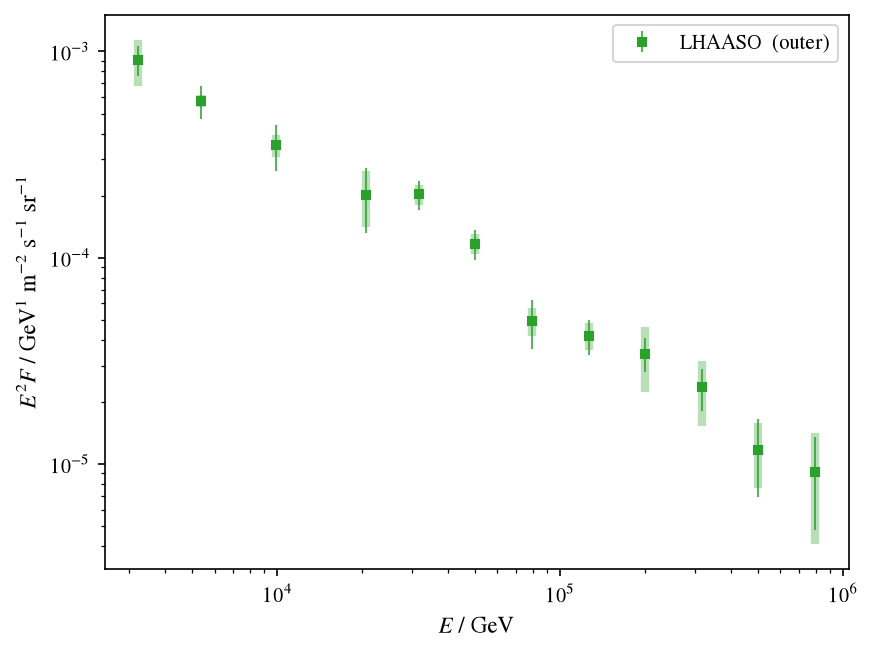

In [3]:
ax = gamma_outer.plot(scale=2, use_cr_spectrum_label=False)
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()

In [4]:
import csv


def _read_elementary(
    fname: str = "../out/phase-6/hermes-products/fiducial-grid/production/2pop_all_lower/lhaaso-spectra.csv",
    gas="HI",
    absorption="unabsorbed",
    window="l015-125-b05",
):
    with open(fname) as f:
        E = []
        y = []
        r = csv.DictReader(f)
        all_gas = set()
        all_abs = set()
        all_window = set()
        for row in r:
            all_gas.add(row["gas"])
            all_abs.add(row["absorption"])
            all_window.add(row["window"])
            if row["gas"] == gas and row["absorption"] == absorption and row["window"] == window:
                E.append(float(row["energy_tev"]) * 1e3)
                y.append(float(row["mean_intensity_tev-1_cm-2_s-1_sr-1"]) * 1e-3 * 1e4)
    return np.array(E), np.array(y)


def read_prediction(
    fname: str = "../out/phase-6/hermes-products/fiducial-grid/production/2pop_all_lower/lhaaso-spectra.csv",
    absorption="unabsorbed",
    window="l015-125-b05",
):
    E, h1 = _read_elementary(fname, "HI", absorption, window)
    E2, h2 = _read_elementary(fname, "H2", absorption, window)
    assert np.allclose(E, E2)
    return E, h1 + h2

In [5]:
DIR = "../out/phase-6/hermes-products/fiducial-grid/production/"


def read_prediction_band(
    dir_stem: str = "2pop_all",
    is_absorbed: bool = True,
    is_outer: bool = True,
):
    window = "l125-235-b05" if is_outer else "l015-125-b05"
    absorption = "unabsorbed" if not is_absorbed else "cmb-absorbed"
    lines = []
    for suffix in ("fiducial", "lower", "upper"):
        E, line = read_prediction(
            fname=DIR + dir_stem + "_" + suffix + "/lhaaso-spectra.csv",
            absorption=absorption,
            window=window,
        )
        lines.append(line)
    return E, *lines

  message: Optimization terminated successfully.
  success: True
      fun: 31.99594382081901
        x: [ 1.092e+00]
 hess_inv: ┌────┬─────────┐
           │    │      x0 │
           ├────┼─────────┤
           │ x0 │ 0.00437 │
           └────┴─────────┘
     nfev: 13
     njev: 0
   minuit: ┌─────────────────────────────────────────────────────────────────────────┐
           │                                Migrad                                   │
           ├──────────────────────────────────┬──────────────────────────────────────┤
           │ FCN = 32                         │              Nfcn = 13               │
           │ EDM = 8.71e-20 (Goal: 0.0001)    │                                      │
           ├──────────────────────────────────┼──────────────────────────────────────┤
           │          Valid Minimum           │   Below EDM threshold (goal x 10)    │
           ├──────────────────────────────────┼──────────────────────────────────────┤
           │      N

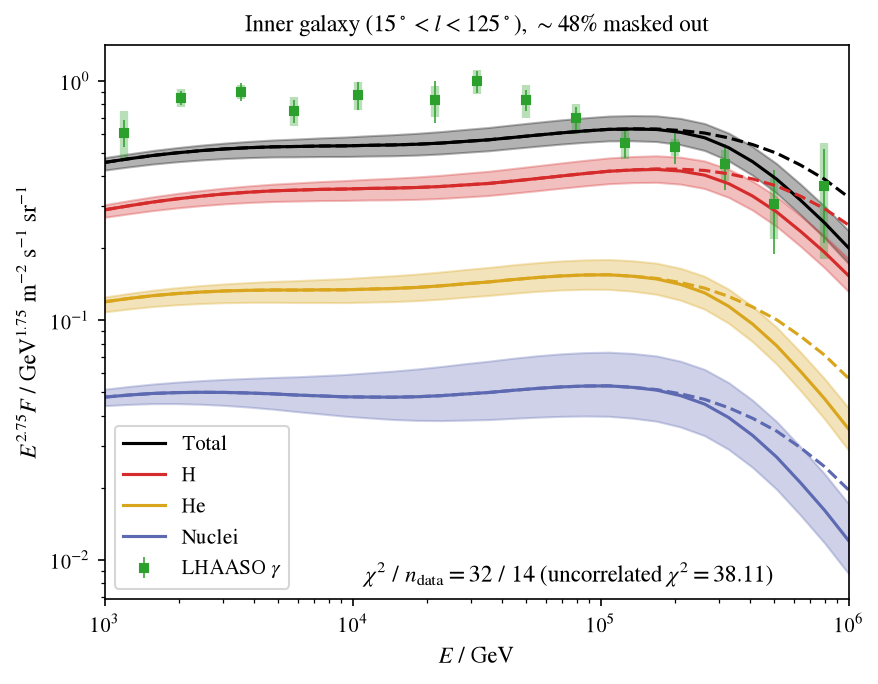

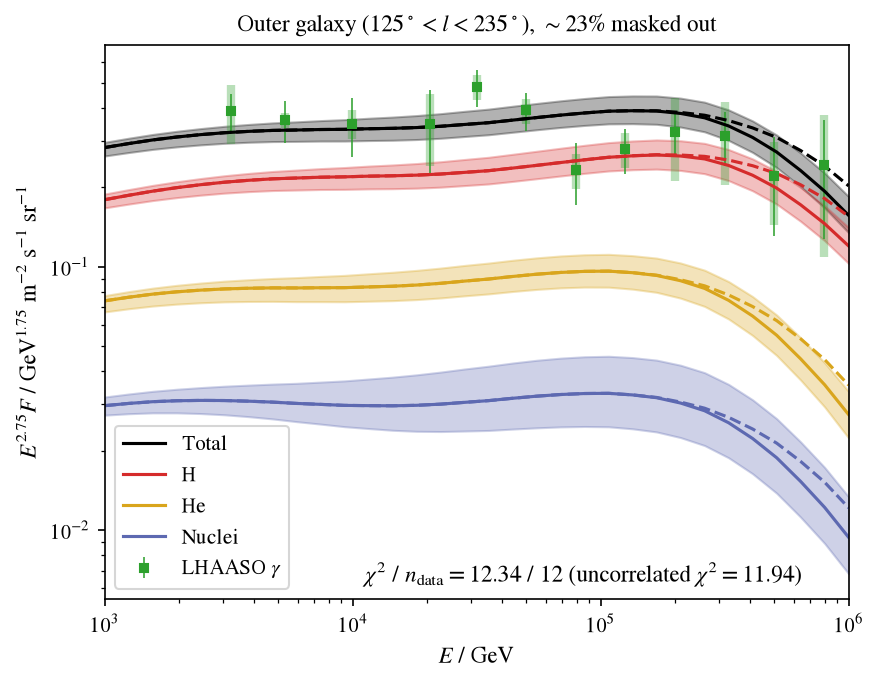

In [ ]:
import iminuit

from cr_knee_fit.elements import Element
from cr_knee_fit.inference import chi_squared_loglikelihood
from cr_knee_fit.plotting import CARTO_VIVID

for is_outer in (False, True):
    scale = 2.75

    gamma = gamma_outer if is_outer else gamma_inner
    ax = gamma.plot(scale=scale)

    E, center, lower, upper = read_prediction_band(dir_stem="2pop_all", is_outer=is_outer)
    prediction = np.interp(gamma.E, E, center)

    if not is_outer:

        def nll(shift: float) -> float:
            return -2 * chi_squared_loglikelihood(
                prediction=prediction * shift,  # noqa: B023
                y=gamma.F,  # noqa: B023
                err_stat=gamma.F_err_stat,  # noqa: B023
                err_syst=gamma.F_err_syst,  # noqa: B023
                inv_err_cov=gamma.d.standard_inv_err_cov,  # noqa: B023
                method="correlated",
            )

        res = iminuit.minimize(nll, 1.0)
        print(res)
        shift = float(res.x[0])
    else:
        shift = 1.0

    # chi2 calculation

    chi2s = []
    for method in ("correlated", "dimidated"):
        chi2s.append(
            -2
            * chi_squared_loglikelihood(
                prediction=prediction * shift,
                y=gamma.F,
                err_stat=gamma.F_err_stat,
                err_syst=gamma.F_err_syst,
                inv_err_cov=gamma.d.standard_inv_err_cov,
                method=method,
            )
        )

    chi2_main = chi2s[0]
    res = f"$\\chi^2 \\; / \\; n_\\text{{data}} = {chi2_main:.4g} \\; / \\; {gamma.size()}$"
    if len(chi2s) > 1:
        res += f" (uncorrelated $\\chi^2 = {chi2s[1]:.4g}$)"

    print(res)

    # plotting
    for suffix, color, label in (
        ("all", "k", "Total"),
        ("H", Element.H.color, "H"),
        ("He", Element.He.color, "He"),
        ("nuclei", CARTO_VIVID(1), "Nuclei"),
    ):
        E, center, lower, upper = read_prediction_band(dir_stem=f"2pop_{suffix}", is_outer=is_outer)
        ax.loglog(E, E**scale * center, color=color, label=label)
        ax.fill_between(E, E**scale * lower, E**scale * upper, alpha=0.3, color=color)

        E, center, lower, upper = read_prediction_band(
            dir_stem=f"2pop_{suffix}", is_outer=is_outer, is_absorbed=False
        )
        ax.loglog(E, E**scale * center, color=color, ls="--")

    ax.text(0.35, 0.03, res, ha="left", va="baseline", transform=ax.transAxes)
    ax.legend()
    ax.set_xlim(E[0], E[-1])

    if is_outer:
        ax.set_title("Outer galaxy ($ 125^\\circ < l < 235^\\circ $), $\\sim 23\\%$ masked out")
    else:
        ax.set_title("Inner galaxy ($ 15^\\circ < l < 125^\\circ $), $\\sim 48\\%$ masked out")

In [7]:
import iminuit

is_outer = False

gamma = gamma_outer if is_outer else gamma_inner
E, center, lower, upper = read_prediction_band(dir_stem="2pop_all", is_outer=is_outer)
prediction = np.interp(gamma.E, E, center)